<a href="https://colab.research.google.com/github/BhaveshJoshi934/RTR2020/blob/master/LassoRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

MI_NAVY = "#004B8D"
MI_GOLD = "#D1AB65"
MI_LIGHT = "#3D8FD6"
MI_RED = "#C0392B"

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 11

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
np.random.seed(42)

In [2]:
df = pd.read_csv("IPL_2008_-_2026-Lasso.csv")
print("Shape:", df.shape)
df.head()

Shape: (1218, 31)


,date,season,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,team2_runs,team2_wickets,winner,result_type,win_by_runs,win_by_wickets,player_of_match,match_referee,umpire1,umpire2,tv_umpire,reserve_umpire,overs_limit,team1_players,team2_players,team1_wickets_remaining,team2_run_rate,total_wickets_fell,run_margin_dup,wicket_margin_dup,team2_runs_x2
0,18-04-2008,2008,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,82,10,222,3,Kolkata Knight Riders,complete,140,0,BB McCullum,J Srinath,Asad Rauf,RE Koertzen,AM Saheba,VN Kulkarni,20,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey...",0,11.10,13,140.0,0.0,444.0
1,19-04-2008,2008,Chandigarh,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,207,4,240,5,Chennai Super Kings,complete,33,0,MEK Hussey,S Venkataraghavan,MR Benson,SL Shastri,RB Tiffin,MSS Ranawat,20,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ...",6,12.00,9,33.0,0.0,480.0
2,19-04-2008,2008,Delhi,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,132,1,129,8,Delhi Daredevils,complete,0,9,MF Maharoof,GR Viswanath,Aleem Dar,GA Pratapkumar,IL Howell,Unknown,20,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm...",9,6.45,9,0.0,9.0,258.0
3,20-04-2008,2008,Kolkata,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,112,5,110,10,Kolkata Knight Riders,complete,0,5,DJ Hussey,FM Engineer,BF Bowden,K Hariharan,Asad Rauf,F Gomes,20,"WP Saha, BB McCullum, RT Ponting, SC Ganguly, ...","AC Gilchrist, Y Venugopal Rao, VVS Laxman, A S...",5,5.50,15,0.0,5.0,220.0
4,20-04-2008,2008,Mumbai,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,165,7,166,5,Royal Challengers Bangalore,complete,0,5,MV Boucher,J Srinath,SJ Davis,DJ Harper,AV Jayaprakash,SN Bandekar,20,"L Ronchi, ST Jayasuriya, DJ Thornely, RV Uthap...","S Chanderpaul, R Dravid, LRPL Taylor, JH Kalli...",3,8.30,12,0.0,5.0,332.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     1218 non-null   object 
 1   season                   1218 non-null   object 
 2   city                     1218 non-null   object 
 3   venue                    1218 non-null   object 
 4   team1                    1218 non-null   object 
 5   team2                    1218 non-null   object 
 6   toss_winner              1218 non-null   object 
 7   toss_decision            1218 non-null   object 
 8   team1_runs               1218 non-null   int64  
 9   team1_wickets            1218 non-null   int64  
 10  team2_runs               1218 non-null   int64  
 11  team2_wickets            1218 non-null   int64  
 12  winner                   1218 non-null   object 
 13  result_type              1218 non-null   object 
 14  win_by_runs             

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
team1_runs,1218.0,166.224138,34.885513,58.0,144.0,165.0,188.75,287.00
team1_wickets,1218.0,5.954844,2.301533,0.0,4.0,6.0,8.00,10.00
team2_runs,1218.0,158.112479,32.574213,44.0,138.0,160.0,179.00,265.00
team2_wickets,1218.0,5.885878,2.615160,0.0,4.0,6.0,8.00,10.00
win_by_runs,1218.0,14.218391,24.020840,0.0,0.0,0.0,20.00,146.00
win_by_wickets,1218.0,3.344007,3.359195,0.0,0.0,3.0,6.00,10.00
overs_limit,1218.0,20.000000,0.000000,20.0,20.0,20.0,20.00,20.00
team1_wickets_remaining,1218.0,4.045156,2.301533,0.0,2.0,4.0,6.00,10.00
team2_run_rate,1218.0,7.905624,1.628711,2.2,6.9,8.0,8.95,13.25
total_wickets_fell,1218.0,11.840722,3.053225,3.0,10.0,12.0,14.00,20.00


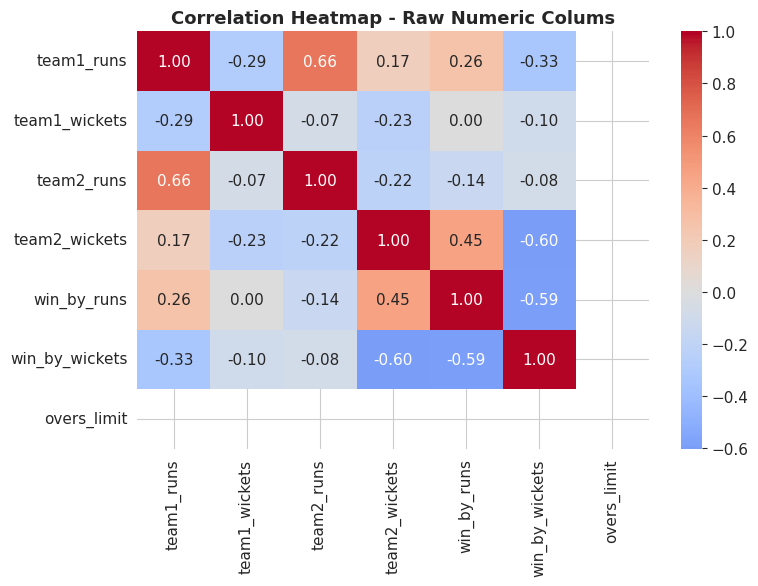

In [5]:
numeric_raw = ["team1_runs", "team1_wickets", "team2_runs", "team2_wickets", "win_by_runs", "win_by_wickets", "overs_limit"]
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(df[numeric_raw].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap - Raw Numeric Colums", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [9]:
numeric_cols = ["team1_wickets", "team2_runs", "team2_wickets", "win_by_runs", "win_by_wickets", "overs_limit", "team1_wickets_remaining", "team2_run_rate", "total_wickets_fell", "run_margin_dup", "wicket_margin_dup", "team2_runs_x2"]
categorical_cols = ["team1", "team2", "venue", "city", "toss_winner", "toss_decision", "season", "player_of_match"]
X = pd.get_dummies(df[categorical_cols + numeric_cols], columns=categorical_cols, drop_first=True)
y = df["team1_runs"]

print("Final Feature Matrix Shape:", X.shape)
print("Number of rows :", len(df))
print(f"Feature-To-Rows ratio: {X.shape[1] / len(df):.2f}")

Final Feature Matrix Shape: (1218, 500)
Number of rows : 1218
Feature-To-Rows ratio: 0.41


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scalar = StandardScaler()
X_train_s = scalar.fit_transform(X_train)
X_test_s = scalar.transform(X_test)

print("Train shape:", X_train_s.shape)
print("Test shape:", X_test_s.shape)

Train shape: (913, 500)
Test shape: (305, 500)


In [14]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)

lr_train_r2 = r2_score(y_train, lr.predict(X_train_s))
lr_test_r2 = r2_score(y_test, lr.predict(X_test_s))
lr_gap = lr_train_r2 - lr_test_r2

print(f"Linear Regression Train R2 Score: {lr_train_r2:.4f}")
print(f"Linear Regression Test R2 Score: {lr_test_r2:.4f}")
print(f"Train Test Gap (Overfitting signal): {lr_gap:.4f}")

Linear Regression Train R2 Score: 0.8568
Linear Regression Test R2 Score: 0.4717
Train Test Gap (Overfitting signal): 0.3851


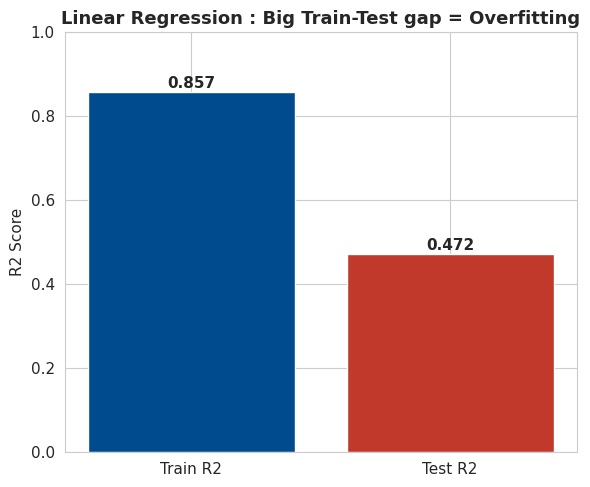

In [18]:
fig, ax = plt.subplots(figsize=(6,5))
bars = ax.bar(["Train R2", "Test R2"], [lr_train_r2, lr_test_r2], color=[MI_NAVY, MI_RED])
for b in bars:
  ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{b.get_height():.3f}", ha="center", fontweight="bold")
ax.set_ylim(0,1)
ax.set_title("Linear Regression : Big Train-Test gap = Overfitting", fontsize=13, fontweight="bold")
ax.set_ylabel("R2 Score")
plt.tight_layout()
plt.show()

In [20]:
lambdas = np.array([0.001, 0.01, 0.1, 1, 5, 10, 20, 50, 100, 200, 300, 500, 800, 1000, 1500, 2000, 3000])
train_scores, test_scores = [], []
for a in lambdas:
  lasso = Lasso(alpha=a)
  lasso.fit(X_train_s, y_train)
  train_scores.append(r2_score(y_train, lasso.predict(X_train_s)))
  test_scores.append(r2_score(y_test, lasso.predict(X_test_s)))
results = pd.DataFrame({"Lambda": lambdas, "Train R2": train_scores, "Test R2": test_scores})
results["gap"] = results["Train R2"] - results["Test R2"]
results

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.131e+02, tolerance: 1.183e+02
  model = cd_fast.enet_coordinate_descent(


,Lambda,Train R2,Test R2,gap
0,0.001,0.856768,0.474497,0.382272
1,0.010,0.856490,0.484553,0.371937
2,0.100,0.848862,0.553117,0.295744
3,1.000,0.752138,0.609567,0.142571
4,5.000,0.591517,0.511577,0.079940
5,10.000,0.411137,0.322212,0.088925
6,20.000,0.162667,0.133830,0.028837
7,50.000,0.000000,-0.000106,0.000106
8,100.000,0.000000,-0.000106,0.000106
9,200.000,0.000000,-0.000106,0.000106


In [22]:
lasso_best = Lasso(alpha=1)
lasso_best.fit(X_train_s, y_train)

lasso_train_r2 = r2_score(y_train, lasso_best.predict(X_train_s))
lasso_test_r2 = r2_score(y_test, lasso_best.predict(X_test_s))
lasso_gap = lasso_train_r2 - lasso_test_r2

print(f"Best Lambda: {1}")
print(f"Lasso Train R2 Score: {lasso_train_r2:.4f}")
print(f"Lasso Test R2 Score: {lasso_test_r2:.4f}")
print(f"Train Test Gap (Overfitting signal): {lasso_gap:.4f}")

Best Lambda: 1
Lasso Train R2 Score: 0.7521
Lasso Test R2 Score: 0.6096
Train Test Gap (Overfitting signal): 0.1426


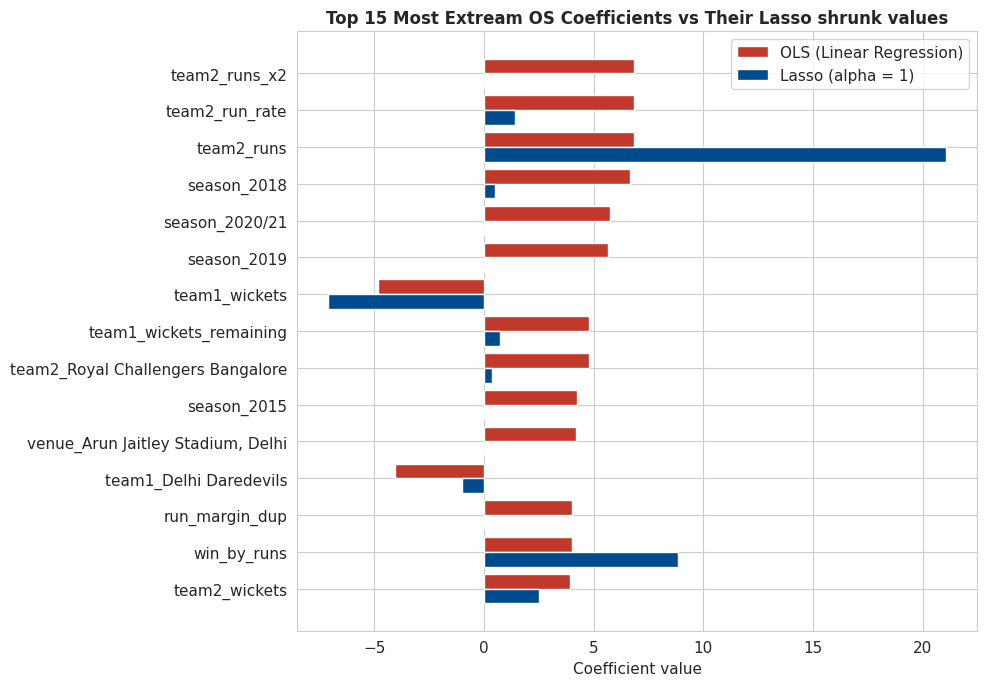

In [31]:
coef_compare = pd.DataFrame({
    "feature": X.columns,
    "OLS_coef": lr.coef_,
    "Lasso_coef": lasso_best.coef_
})
coef_compare["OLS_abs"] = coef_compare["OLS_coef"].abs()
top_unstable = coef_compare.sort_values("OLS_abs", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10,7))
y_pos = np.arange(len(top_unstable))
ax.barh(y_pos - 0.2, top_unstable["OLS_coef"], height=0.4, color=MI_RED, label="OLS (Linear Regression)")
ax.barh(y_pos + 0.2, top_unstable["Lasso_coef"], height=0.4, color=MI_NAVY, label="Lasso (alpha = 1)")
ax.set_yticks(y_pos)
ax.set_yticklabels(top_unstable["feature"])
ax.set_xlabel("Coefficient value")
ax.set_title("Top 15 Most Extream OS Coefficients vs Their Lasso shrunk values", fontsize=12, fontweight="bold")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# print(f"Mean coefficient -> OLS:
# {coef_compare['OLS_coef'].abs().mean():.3f}  Lasso:
# {coef_compare['Lasso_coef'].abs().mean():.3f}")

# print(f"Mean coefficient -> OLS:
# {coef_compare['OLS_coef'].abs().max():.3f}  Lasso:
# {coef_compare['Lasso_coef'].abs().max():.3f}")

In [35]:
summary = pd.DataFrame({
    "Model": ["Linear Regression", f"Lasso (alpha=1)"],
    "Train R2": [lr_train_r2, lasso_train_r2],
    "Test R2": [lr_test_r2, lasso_test_r2],
    "Train-Test Gap": [lr_gap, lasso_gap]
})
summary

,Model,Train R2,Test R2,Train-Test Gap
0,Linear Regression,0.856788,0.471710,0.385078
1,Lasso (alpha=1),0.752138,0.609567,0.142571


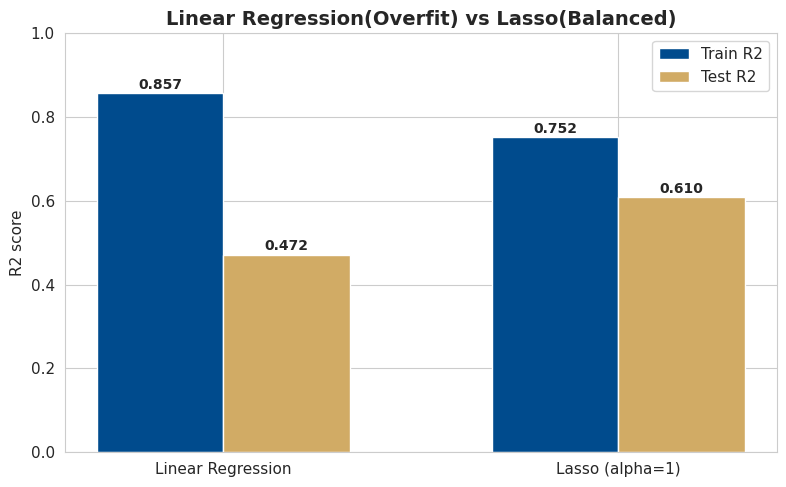

In [38]:
fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(2)
width = 0.32

bars1 = ax.bar(x - width/2, summary["Train R2"], width, color=MI_NAVY, label="Train R2")
bars2 = ax.bar(x + width/2, summary["Test R2"], width, color=MI_GOLD, label="Test R2")

for b in list(bars1) + list(bars2):
  ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{b.get_height():.3f}", ha="center", fontweight="bold", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(summary["Model"])
ax.set_ylim(0,1)
ax.set_ylabel("R2 score")
ax.set_title("Linear Regression(Overfit) vs Lasso(Balanced)", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()